In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [13]:
strict_clean_big5 = pd.read_csv('Datasets/cleaned_big5_totals.csv')
trait_total_columns = ['O_total', 'C_total', 'E_total', 'A_total', 'N_total']
strict_clean_trait_totals = strict_clean_big5[trait_total_columns].copy()

trait_scaler = StandardScaler()
standardized_trait_totals = pd.DataFrame(
    trait_scaler.fit_transform(strict_clean_trait_totals),
    columns=trait_total_columns,
    index=strict_clean_trait_totals.index
)
print("Cleaned data loaded and standardized!")

Cleaned data loaded and standardized!


a. introduction to the topic and what it is

The Big Five is a personality framework with five traits: Openness, Conscientiousness, Extraversion, Agreeableness, and Neuroticism. We are predicting each personality trait.

b. plotting the data (qq plot and heatmaps)

We plot Q-Q plots to check normal distribution and heatmaps to check correlation.

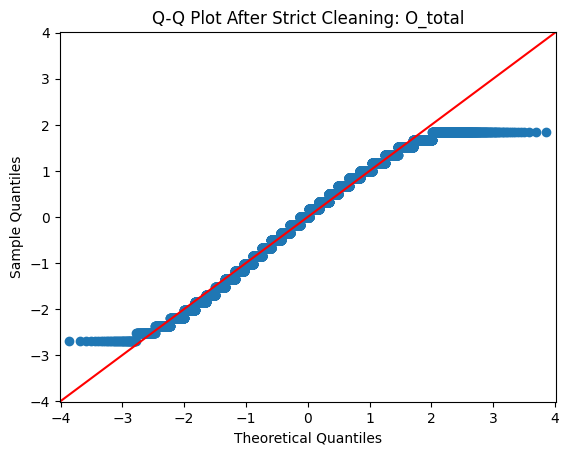

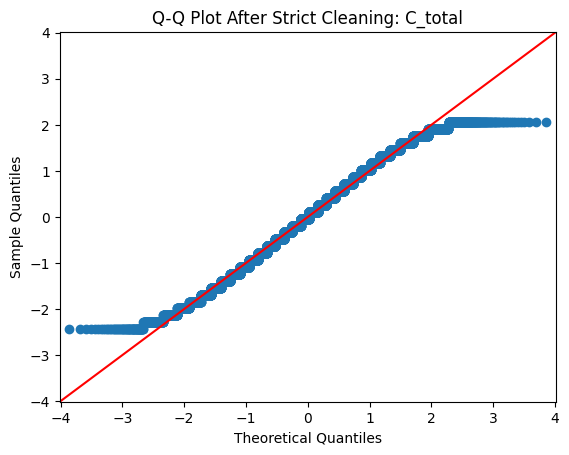

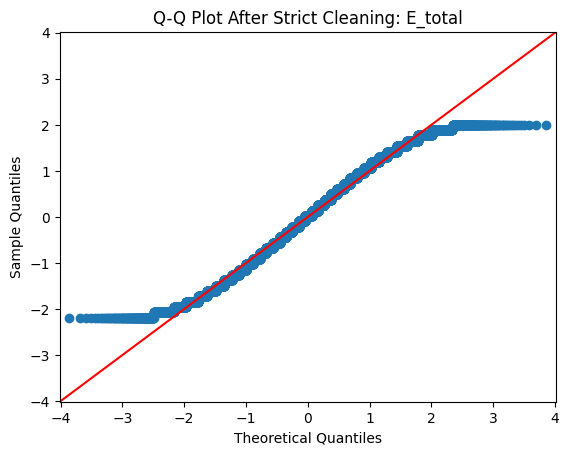

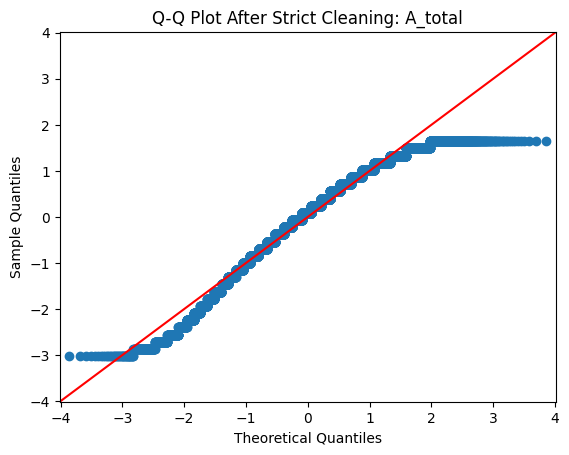

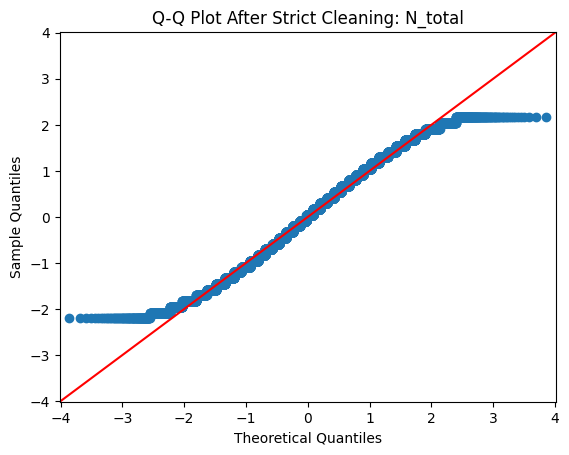

In [14]:
for trait_total_column in trait_total_columns:
    sm.qqplot(strict_clean_trait_totals[trait_total_column], line='45', fit=True)
    plt.title(f'Q-Q Plot After Strict Cleaning: {trait_total_column}')
    plt.savefig(f'plots/qq_plot_{trait_total_column}.png', bbox_inches='tight')
    plt.show()

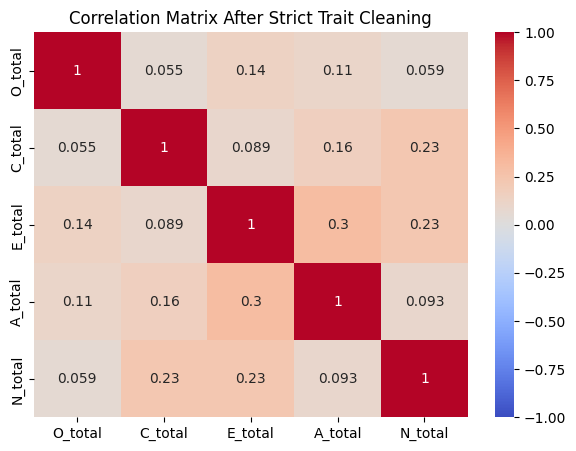

,O_total,C_total,E_total,A_total,N_total
O_total,1.000000,0.055215,0.135544,0.106185,0.059433
C_total,0.055215,1.000000,0.088611,0.158345,0.227897
E_total,0.135544,0.088611,1.000000,0.302306,0.230845
A_total,0.106185,0.158345,0.302306,1.000000,0.093205
N_total,0.059433,0.227897,0.230845,0.093205,1.000000


In [15]:
trait_order = ['O_total', 'C_total', 'E_total', 'A_total', 'N_total']
trait_correlation_matrix = standardized_trait_totals[trait_order].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(trait_correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix After Strict Trait Cleaning')
plt.savefig('plots/correlation_matrix.png', bbox_inches='tight')
plt.show()

trait_correlation_matrix

c. confirming observation from plots that the traits do not correlate

Observing the Q-Q plots and heatmaps, we confirm that the traits do not correlate strongly.

d. formulating the hypothesis test that each trait is independent, test by training the model 500 times on different parts of the dataset, obtain the mean and then test the hypothesis that each weight is insignificant, and do this for each trait. find an efficient way to do so.

Two models are made on the data as a matrix for predicting each personality trait.

In [16]:
train_trait_data, test_trait_data = train_test_split(
    standardized_trait_totals,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

holdout_model_records = []

for target_trait_column in trait_total_columns:
    predictor_trait_columns = [
        column_name for column_name in trait_total_columns
        if column_name != target_trait_column
    ]

    training_predictors = train_trait_data[predictor_trait_columns]
    training_target = train_trait_data[target_trait_column]
    testing_predictors = test_trait_data[predictor_trait_columns]
    testing_target = test_trait_data[target_trait_column]

    holdout_model = LinearRegression()
    holdout_model.fit(training_predictors, training_target)

    training_predictions = holdout_model.predict(training_predictors)
    testing_predictions = holdout_model.predict(testing_predictors)

    holdout_model_records.append({
        'target': target_trait_column,
        'train_rows': len(train_trait_data),
        'test_rows': len(test_trait_data),
        'train_r2': r2_score(training_target, training_predictions),
        'test_r2': r2_score(testing_target, testing_predictions)
    })

holdout_validation_summary_df = pd.DataFrame(holdout_model_records).sort_values('target').reset_index(drop=True)
holdout_validation_summary_df

,target,train_rows,test_rows,train_r2,test_r2
0,A_total,13971,3493,0.113638,0.107559
1,C_total,13971,3493,0.068435,0.084319
2,E_total,13971,3493,0.141775,0.141188
3,N_total,13971,3493,0.093079,0.112526
4,O_total,13971,3493,0.022168,0.031665


In [17]:
all_target_weight_records = []

for target_trait_column in trait_total_columns:
    predictor_trait_columns = [
        column_name for column_name in trait_total_columns
        if column_name != target_trait_column
    ]
    predictor_data = standardized_trait_totals[predictor_trait_columns]
    target_data = standardized_trait_totals[target_trait_column]

    linear_regression_model = LinearRegression()
    linear_regression_model.fit(predictor_data, target_data)

    for predictor_trait_column, model_weight in zip(predictor_trait_columns, linear_regression_model.coef_):
        all_target_weight_records.append({
            'target': target_trait_column,
            'predictor': predictor_trait_column,
            'weight': model_weight,
            'intercept': linear_regression_model.intercept_,
            'train_r2': linear_regression_model.score(predictor_data, target_data)
        })

all_target_weights_df = pd.DataFrame(all_target_weight_records)
all_target_weights_df = all_target_weights_df.sort_values(['target', 'predictor']).reset_index(drop=True)
all_target_weights_df

,target,predictor,weight,intercept,train_r2
0,A_total,C_total,0.131165,3.983323e-16,0.112475
1,A_total,E_total,0.283781,3.983323e-16,0.112475
2,A_total,N_total,-0.005811,3.983323e-16,0.112475
3,A_total,O_total,0.060823,3.983323e-16,0.112475
4,C_total,A_total,0.137189,-2.142864e-16,0.071715
5,C_total,E_total,-0.006359,-2.142864e-16,0.071715
6,C_total,N_total,0.214871,-2.142864e-16,0.071715
7,C_total,O_total,0.028739,-2.142864e-16,0.071715
8,E_total,A_total,0.274441,-2.767854e-16,0.141685
9,E_total,C_total,-0.005880,-2.767854e-16,0.141685


In [18]:
significance_levels = [0.10, 0.05, 0.01]
number_of_repetitions = 500
random_sample_size = 70
random_seed = 42
practical_partial_r2_threshold = 0.01

if len(standardized_trait_totals) < random_sample_size:
    raise ValueError(
        f'Not enough rows for sample size {random_sample_size}. '
        f'Available rows: {len(standardized_trait_totals)}'
    )

random_generator = np.random.default_rng(random_seed)
repeated_ols_result_records = []
sampling_audit_records = []

for repetition_index in range(number_of_repetitions):
    sampled_row_indices = random_generator.choice(
        standardized_trait_totals.index.to_numpy(),
        size=random_sample_size,
        replace=False
    )
    sampled_trait_data = standardized_trait_totals.loc[sampled_row_indices].reset_index(drop=True)

    sampling_audit_records.append({
        'repetition': repetition_index,
        'sample_size': len(sampled_row_indices),
        'unique_rows_in_sample': len(np.unique(sampled_row_indices))
    })

    for target_trait_column in trait_total_columns:
        predictor_trait_columns = [
            column_name for column_name in trait_total_columns
            if column_name != target_trait_column
        ]
        target_vector = sampled_trait_data[target_trait_column]

        full_design_matrix = sm.add_constant(sampled_trait_data[predictor_trait_columns])
        full_ols_model = sm.OLS(target_vector, full_design_matrix).fit()
        residual_sum_squares_full = float(np.sum(full_ols_model.resid ** 2))

        for removed_predictor_column in predictor_trait_columns:
            reduced_predictor_columns = [
                column_name for column_name in predictor_trait_columns
                if column_name != removed_predictor_column
            ]
            reduced_design_matrix = sm.add_constant(sampled_trait_data[reduced_predictor_columns])
            reduced_ols_model = sm.OLS(target_vector, reduced_design_matrix).fit()
            residual_sum_squares_reduced = float(np.sum(reduced_ols_model.resid ** 2))

            numerator_degrees_of_freedom = 1
            denominator_degrees_of_freedom = int(full_ols_model.df_resid)

            numerator_component = max(
                (residual_sum_squares_reduced - residual_sum_squares_full) / numerator_degrees_of_freedom,
                0.0
            )
            denominator_component = (
                residual_sum_squares_full / denominator_degrees_of_freedom
                if denominator_degrees_of_freedom > 0 else np.nan
            )
            partial_f_statistic = (
                numerator_component / denominator_component
                if denominator_component and not np.isnan(denominator_component) else np.nan
            )
            partial_f_p_value = (
                stats.f.sf(partial_f_statistic, numerator_degrees_of_freedom, denominator_degrees_of_freedom)
                if not np.isnan(partial_f_statistic) else np.nan
            )

            partial_r2_value = (
                (residual_sum_squares_reduced - residual_sum_squares_full) / residual_sum_squares_reduced
                if residual_sum_squares_reduced > 0 else np.nan
            )
            partial_r2_value = max(partial_r2_value, 0.0) if not np.isnan(partial_r2_value) else np.nan

            repeated_ols_result_records.append({
                'repetition': repetition_index,
                'target': target_trait_column,
                'predictor': removed_predictor_column,
                'coefficient': full_ols_model.params[removed_predictor_column],
                'coefficient_p_value': full_ols_model.pvalues[removed_predictor_column],
                'partial_f_statistic': partial_f_statistic,
                'partial_f_p_value': partial_f_p_value,
                'partial_r2': partial_r2_value,
                'model_r2': full_ols_model.rsquared,
                'model_adj_r2': full_ols_model.rsquared_adj
            })

sampling_audit_df = pd.DataFrame(sampling_audit_records)
if len(sampling_audit_df) != number_of_repetitions:
    raise AssertionError('Sampling did not produce the expected number of repetitions.')
if not (sampling_audit_df['sample_size'] == random_sample_size).all():
    raise AssertionError('At least one sample did not contain exactly 70 rows.')
if not (sampling_audit_df['unique_rows_in_sample'] == random_sample_size).all():
    raise AssertionError('At least one sample contains duplicated rows.')

repeated_ols_results_df = pd.DataFrame(repeated_ols_result_records)

print(f'Repetition audit: {len(sampling_audit_df)} samples generated with {random_sample_size} rows each.')
repeated_ols_results_df.head()

Repetition audit: 500 samples generated with 70 rows each.


,repetition,target,predictor,coefficient,coefficient_p_value,partial_f_statistic,partial_f_p_value,partial_r2,model_r2,model_adj_r2
0,0,O_total,C_total,-0.031993,0.815071,0.055150,0.815071,0.000848,0.034022,-0.025423
1,0,O_total,E_total,0.161529,0.275038,1.211788,0.275038,0.018302,0.034022,-0.025423
2,0,O_total,A_total,0.092737,0.516756,0.424990,0.516756,0.006496,0.034022,-0.025423
3,0,O_total,N_total,0.028349,0.850540,0.035790,0.850540,0.000550,0.034022,-0.025423
4,0,C_total,O_total,-0.026498,0.815071,0.055150,0.815071,0.000848,0.061684,0.003942


In [19]:
def compute_mean_and_ci(values, alpha=0.05):
    values_array = np.asarray(values, dtype=float)
    values_array = values_array[~np.isnan(values_array)]
    sample_count = len(values_array)

    if sample_count < 2:
        return np.nan, np.nan, np.nan

    mean_value = values_array.mean()
    standard_error = stats.sem(values_array, nan_policy='omit')
    critical_t_value = stats.t.ppf(1 - alpha / 2, df=sample_count - 1)

    ci_lower_bound = mean_value - critical_t_value * standard_error
    ci_upper_bound = mean_value + critical_t_value * standard_error

    return mean_value, ci_lower_bound, ci_upper_bound

summary_records = []

for (target_trait_column, predictor_trait_column), grouped_results in repeated_ols_results_df.groupby(['target', 'predictor']):
    coefficient_mean = grouped_results['coefficient'].mean()
    coefficient_std = grouped_results['coefficient'].std(ddof=1)

    partial_r2_mean, partial_r2_ci_lower, partial_r2_ci_upper = compute_mean_and_ci(
        grouped_results['partial_r2'].values
    )

    summary_row = {
        'target': target_trait_column,
        'predictor': predictor_trait_column,
        'coefficient_mean': coefficient_mean,
        'coefficient_std': coefficient_std,
        'partial_r2_mean': partial_r2_mean,
        'partial_r2_ci_low_95': partial_r2_ci_lower,
        'partial_r2_ci_high_95': partial_r2_ci_upper,
        'practical_non_importance': (
            bool(partial_r2_ci_upper < practical_partial_r2_threshold)
            if not np.isnan(partial_r2_ci_upper) else False
        )
    }

    for significance_level in significance_levels:
        summary_row[f'non_sig_rate_coef_p(alpha={significance_level})'] = (
            grouped_results['coefficient_p_value'] > significance_level
        ).mean()
        summary_row[f'non_sig_rate_partial_f(alpha={significance_level})'] = (
            grouped_results['partial_f_p_value'] > significance_level
        ).mean()

    summary_records.append(summary_row)

repeated_ols_summary_df = pd.DataFrame(summary_records)
repeated_ols_summary_df = repeated_ols_summary_df.sort_values(['target', 'predictor']).reset_index(drop=True)
repeated_ols_summary_df

,target,predictor,coefficient_mean,coefficient_std,partial_r2_mean,partial_r2_ci_low_95,partial_r2_ci_high_95,practical_non_importance,non_sig_rate_coef_p(alpha=0.1),non_sig_rate_partial_f(alpha=0.1),non_sig_rate_coef_p(alpha=0.05),non_sig_rate_partial_f(alpha=0.05),non_sig_rate_coef_p(alpha=0.01),non_sig_rate_partial_f(alpha=0.01)
0,A_total,C_total,0.140258,0.125297,0.036954,0.033364,0.040544,False,0.650,0.650,0.752,0.752,0.912,0.912
1,A_total,E_total,0.281554,0.132631,0.091498,0.085648,0.097347,False,0.262,0.262,0.364,0.364,0.592,0.592
2,A_total,N_total,-0.009501,0.130101,0.016756,0.014770,0.018743,False,0.876,0.876,0.940,0.940,0.988,0.988
3,A_total,O_total,0.062119,0.118080,0.020005,0.017510,0.022499,False,0.864,0.864,0.918,0.918,0.968,0.968
4,C_total,A_total,0.149321,0.134438,0.036954,0.033364,0.040544,False,0.650,0.650,0.752,0.752,0.912,0.912
5,C_total,E_total,-0.001085,0.130150,0.015163,0.013259,0.017068,False,0.900,0.900,0.952,0.952,0.988,0.988
6,C_total,N_total,0.215109,0.129261,0.059316,0.054602,0.064031,False,0.464,0.464,0.612,0.612,0.812,0.812
7,C_total,O_total,0.021680,0.119056,0.015018,0.013187,0.016849,False,0.898,0.898,0.944,0.944,0.994,0.994
8,E_total,A_total,0.272982,0.125968,0.091498,0.085648,0.097347,False,0.262,0.262,0.364,0.364,0.592,0.592
9,E_total,C_total,-0.002508,0.119120,0.015163,0.013259,0.017068,False,0.900,0.900,0.952,0.952,0.988,0.988


e. testing the hypothesis at different significance levels and printing the conclusion for each.

In [20]:
overall_target_model_summary_df = (
    repeated_ols_results_df.groupby('target')[['model_r2', 'model_adj_r2']]
    .agg(['mean', 'std'])
)
overall_target_model_summary_df

model_r2           model_adj_r2          
             mean       std         mean       std
target                                            
A_total  0.169406  0.076884     0.118292  0.081616
C_total  0.128791  0.067171     0.075178  0.071304
E_total  0.193870  0.082586     0.144262  0.087669
N_total  0.150149  0.073345     0.097850  0.077859
O_total  0.081027  0.051011     0.024475  0.054150

In [21]:
for idx, row in repeated_ols_summary_df.iterrows():
    target = row['target']
    predictor = row['predictor']
    for alpha in significance_levels:
        non_sig_rate = row[f'non_sig_rate_coef_p(alpha={alpha})']
        # If the non-significance rate is high across the 500 repetitions, the weight is insignificant
        if non_sig_rate > 0.5:
            conclusion = "insignificant weight (independent)"
        else:
            conclusion = "significant weight (not independent)"
            
        print(f"Target: {target} | Predictor: {predictor} | Alpha: {alpha} | Conclusion: {conclusion}")


Target: A_total | Predictor: C_total | Alpha: 0.1 | Conclusion: insignificant weight (independent)
Target: A_total | Predictor: C_total | Alpha: 0.05 | Conclusion: insignificant weight (independent)
Target: A_total | Predictor: C_total | Alpha: 0.01 | Conclusion: insignificant weight (independent)
Target: A_total | Predictor: E_total | Alpha: 0.1 | Conclusion: significant weight (not independent)
Target: A_total | Predictor: E_total | Alpha: 0.05 | Conclusion: significant weight (not independent)
Target: A_total | Predictor: E_total | Alpha: 0.01 | Conclusion: insignificant weight (independent)
Target: A_total | Predictor: N_total | Alpha: 0.1 | Conclusion: insignificant weight (independent)
Target: A_total | Predictor: N_total | Alpha: 0.05 | Conclusion: insignificant weight (independent)
Target: A_total | Predictor: N_total | Alpha: 0.01 | Conclusion: insignificant weight (independent)
Target: A_total | Predictor: O_total | Alpha: 0.1 | Conclusion: insignificant weight (independent)


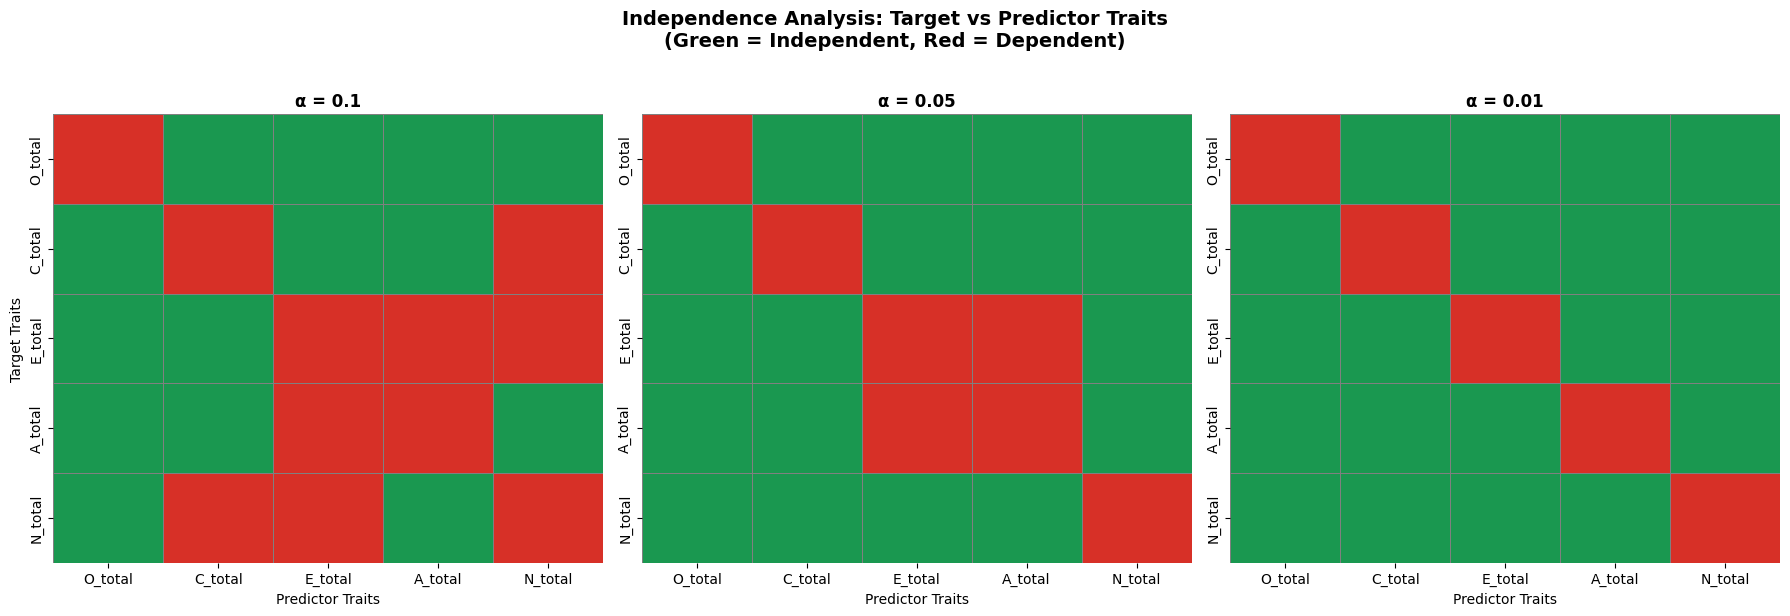

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

alphas = [0.10, 0.05, 0.01]
trait_order = ['O_total', 'C_total', 'E_total', 'A_total', 'N_total']
target_traits = [trait for trait in trait_order if trait in repeated_ols_summary_df['target'].unique()]
predictor_traits = [trait for trait in trait_order if trait in repeated_ols_summary_df['predictor'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Independence Analysis: Target vs Predictor Traits\n(Green = Independent, Red = Dependent)', 
             fontsize=14, fontweight='bold', y=1.02)

for idx, alpha in enumerate(alphas):
    heatmap_data = np.zeros((len(target_traits), len(predictor_traits)))
    col_name = f'non_sig_rate_coef_p(alpha={alpha})'
    
    for i, target in enumerate(target_traits):
        for j, predictor in enumerate(predictor_traits):
            row = repeated_ols_summary_df[
                (repeated_ols_summary_df['target'] == target) & 
                (repeated_ols_summary_df['predictor'] == predictor)
            ]
            if not row.empty:
                non_sig_rate = row[col_name].values[0]
                heatmap_data[i, j] = 1 if non_sig_rate > 0.5 else 0
    
    sns.heatmap(
        heatmap_data, 
        ax=axes[idx],
        cmap=sns.color_palette(['#d73027', '#1a9850'], as_cmap=True),
        cbar=False, xticklabels=predictor_traits, yticklabels=target_traits,
        linewidths=0.5, linecolor='gray', vmin=0, vmax=1
    )
    axes[idx].set_title(f'α = {alpha}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predictor Traits', fontsize=10)
    if idx == 0:
        axes[idx].set_ylabel('Target Traits', fontsize=10)

plt.tight_layout()
plt.savefig('plots/independence_analysis.png', bbox_inches='tight')
plt.show()